In [1]:
import sys
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

## Reduce Data to 4M "without affecting rare attacks"

In [2]:
file_path = "cic.csv"
output_file = "reduced_4m.csv"

if os.path.exists(output_file):
    os.remove(output_file)

target_total = 4_000_000
target_normal = int(target_total * 0.55)   # 2,200,000
target_attack = int(target_total * 0.45)   # 1,800,000

max_per_attack = 300_000
chunksize = 1_000_000

In [3]:
from collections import Counter

attack_counts = Counter()

for chunk in pd.read_csv(file_path, chunksize=chunksize):
    chunk["Label"] = chunk["Label"].astype(str).str.strip()
    chunk["binary_label"] = np.where(
        chunk["Label"].str.contains("BENIGN", case=False),
        0, 1
    )
    
    attack_only = chunk[chunk["binary_label"] == 1]
    attack_counts.update(attack_only["Label"].value_counts().to_dict())

print(dict(attack_counts))

{'DoS-Hulk': 692036, 'FTP-BruteForce': 201289, 'SSH-BruteForce': 193486, 'DoS-Slowloris': 16786, 'DoS-SlowHTTPTest': 145389, 'DoS-GoldenEye': 51801, 'DDoS': 1391958, 'BruteForce-Web': 2118, 'BruteForce-XSS': 882, 'SQL-Injection': 108, 'Heartbleed': 11, 'PortScan': 158804, 'Bot': 288147, 'Infiltration': 160675}


In [4]:
attack_cap_counts = {
    label: min(count, max_per_attack)
    for label, count in attack_counts.items()
}

final_attack_target = sum(attack_cap_counts.values())
final_normal_target = target_total - final_attack_target

print("Attack after cap:", final_attack_target)
print("Normal needed:", final_normal_target)

Attack after cap: 1819496
Normal needed: 2180504


In [5]:
written_attack = Counter()
written_normal = 0
first_write = True

for chunk in pd.read_csv(file_path, chunksize=chunksize):
    chunk["Label"] = chunk["Label"].astype(str).str.strip()
    chunk["binary_label"] = np.where(
        chunk["Label"].str.contains("BENIGN", case=False),
        0, 1
    )

    # -------- attacks --------
    attack_part_list = []
    attack_chunk = chunk[chunk["binary_label"] == 1]

    for label, group in attack_chunk.groupby("Label"):
        remaining = attack_cap_counts.get(label, 0) - written_attack[label]
        if remaining > 0:
            take_n = min(len(group), remaining)
            attack_part_list.append(group.sample(n=take_n, random_state=42))
            written_attack[label] += take_n

    if attack_part_list:
        attack_part = pd.concat(attack_part_list, ignore_index=True)
    else:
        attack_part = pd.DataFrame(columns=chunk.columns)

    # -------- benign --------
    benign_chunk = chunk[chunk["binary_label"] == 0]
    remaining_normal = final_normal_target - written_normal

    if remaining_normal > 0 and len(benign_chunk) > 0:
        
        take_n = min(len(benign_chunk), remaining_normal)
        benign_part = benign_chunk.sample(n=take_n, random_state=42)
        written_normal += len(benign_part)
    else:
        benign_part = pd.DataFrame(columns=chunk.columns)

    # -------- combine current chunk only --------
    chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)

    if len(chunk_out) > 0:
        chunk_out.to_csv(
            output_file,
            mode="w" if first_write else "a",
            index=False,
            header=first_write
        )
        first_write = False

    print(
        "written_normal =", written_normal,
        "| written_attack =", sum(written_attack.values())
    )
    

written_normal = 741533 | written_attack = 258467
written_normal = 1625841 | written_attack = 374159
written_normal = 2180504 | written_attack = 728549


C:\Users\khebr\AppData\Local\Temp\ipykernel_22604\1638514348.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 989997


C:\Users\khebr\AppData\Local\Temp\ipykernel_22604\1638514348.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 1076690


...

written_normal = 2180504 | written_attack = 1372666
written_normal = 2180504 | written_attack = 1372666


C:\Users\khebr\AppData\Local\Temp\ipykernel_22604\1638514348.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 1597028


C:\Users\khebr\AppData\Local\Temp\ipykernel_22604\1638514348.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_out = pd.concat([attack_part, benign_part], ignore_index=True)


written_normal = 2180504 | written_attack = 1819496


In [6]:
df_small = pd.read_csv(output_file)

print(df_small.shape)
print(df_small["binary_label"].value_counts())
print(df_small["binary_label"].value_counts(normalize=True) * 100)
print(df_small["Label"].value_counts())

(4000000, 80)
binary_label
0    2180504
1    1819496
Name: count, dtype: int64
binary_label
0    54.5126
1    45.4874
Name: proportion, dtype: float64
Label
Benign              2180504
DoS-Hulk             300000
DDoS                 300000
Bot                  288147
FTP-BruteForce       201289
SSH-BruteForce       193486
Infiltration         160675
PortScan             158804
DoS-SlowHTTPTest     145389
DoS-GoldenEye         51801
DoS-Slowloris         16786
BruteForce-Web         2118
BruteForce-XSS          882
SQL-Injection           108
Heartbleed               11
Name: count, dtype: int64


In [7]:
# # read data as chunks + take all attacks in our sample data + sample benign slightly more than attacks 
# file_path = "cic.csv"
# chunks = []

# for chunk in pd.read_csv(file_path, chunksize=1_000_000):

#     chunk["Label"] = chunk["Label"].astype(str).str.strip()

#     chunk["binary_label"] = np.where(
#         chunk["Label"].str.contains("BENIGN", case=False),
#         0, 1
#     )

#     benign = chunk[chunk["binary_label"] == 0]
#     attack = chunk[chunk["binary_label"] == 1]

#     benign_needed = int(len(attack) * 1.5)

#     benign_sample = benign.sample(
#         n=min(len(benign), benign_needed),
#         random_state=42
#     )

#     chunk_sample = pd.concat([benign_sample, attack], ignore_index=True)
#     chunks.append(chunk_sample)

# df_small = pd.concat(chunks, ignore_index=True)

In [8]:
# print(df_small.shape)
# print(df_small["binary_label"].value_counts())
# print(df_small["binary_label"].value_counts(normalize=True) * 100)
# print(df_small["Label"].value_counts())

In [9]:
#del df_small
#del chunks

In [10]:
# # downsample data to 4m trying not to affect rare attacks 

# target_total = 4_000_000
# target_normal = int(target_total * 0.55)
# max_per_attack = 300_000

# attack_balanced = df_small[df_small["binary_label"] == 1].groupby("Label", group_keys=False).apply(
#     lambda x: x.sample(n=min(len(x), max_per_attack), random_state=42)
# )

# print("Attack rows after cap:", len(attack_balanced))
# print(attack_balanced["Label"].value_counts())

In [11]:
# benign_df = df_small[df_small["binary_label"] == 0]

# benign_sample = benign_df.sample(
#     n=min(len(benign_df), target_normal),
#     random_state=42
# )

# del benign_df
# del df_small

# import gc
# gc.collect()

# attack_balanced.to_csv("reduced_4m.csv", index=False)
# benign_sample.to_csv("reduced_4m.csv", mode="a", index=False, header=False)

# del attack_balanced
# del benign_sample
# gc.collect()

# print("Saved to reduced_4m.csv")

In [12]:
df_small.head()

,Dst Port,Protocol,Flow Duration,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,binary_label
0,80,0,11073546,1127.371485,1.444885,0.812748,0.632137,9,7,852,...,412627.0,0.0,412627,412627,5659391.0,0.0,5659391,5659391,DoS-GoldenEye,1
1,80,0,18986272,689.340172,1.053393,0.684705,0.368687,13,7,1456,...,3833090.0,0.0,3833090,3833090,10100000.0,0.0,10100000,10100000,DoS-GoldenEye,1
2,80,0,81650835,0.000000,0.024495,0.024495,0.000000,2,0,0,...,0.0,0.0,0,0,81700000.0,0.0,81700000,81700000,DoS-GoldenEye,1
3,80,0,10709673,378.162807,0.840362,0.466868,0.373494,5,4,525,...,1050.0,0.0,1050,1050,5706169.0,0.0,5706169,5706169,DoS-GoldenEye,1
4,80,0,11748681,1030.413542,1.106507,0.680928,0.425580,8,5,474,...,1046.0,0.0,1046,1046,6745733.0,0.0,6745733,6745733,DoS-GoldenEye,1


In [13]:
def clean_column_names(df_small):
    df_small = df_small.copy()
    df_small.columns = (
        df_small.columns
        .str.strip()
        .str.lower()
        .str.replace('[^a-z0-9]', '_', regex=True)
        .str.replace('_+', '_', regex=True)
        .str.strip('_')  
    )
    return df_small
df_small = clean_column_names(df_small)
df_small.head()

,dst_port,protocol,flow_duration,flow_bytes_s,flow_packets_s,fwd_packets_s,bwd_packets_s,total_fwd_packet,total_bwd_packets,total_length_of_fwd_packet,...,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,binary_label
0,80,0,11073546,1127.371485,1.444885,0.812748,0.632137,9,7,852,...,412627.0,0.0,412627,412627,5659391.0,0.0,5659391,5659391,DoS-GoldenEye,1
1,80,0,18986272,689.340172,1.053393,0.684705,0.368687,13,7,1456,...,3833090.0,0.0,3833090,3833090,10100000.0,0.0,10100000,10100000,DoS-GoldenEye,1
2,80,0,81650835,0.000000,0.024495,0.024495,0.000000,2,0,0,...,0.0,0.0,0,0,81700000.0,0.0,81700000,81700000,DoS-GoldenEye,1
3,80,0,10709673,378.162807,0.840362,0.466868,0.373494,5,4,525,...,1050.0,0.0,1050,1050,5706169.0,0.0,5706169,5706169,DoS-GoldenEye,1
4,80,0,11748681,1030.413542,1.106507,0.680928,0.425580,8,5,474,...,1046.0,0.0,1046,1046,6745733.0,0.0,6745733,6745733,DoS-GoldenEye,1


In [14]:
df_small.columns

Index(['dst_port', 'protocol', 'flow_duration', 'flow_bytes_s',
       'flow_packets_s', 'fwd_packets_s', 'bwd_packets_s', 'total_fwd_packet',
       'total_bwd_packets', 'total_length_of_fwd_packet',
       'total_length_of_bwd_packet', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'packet_length_max', 'packet_length_min',
       'packet_length_mean', 'packet_length_std', 'packet_length_variance',
       'fwd_header_length', 'bwd_header_length', 'fwd_seg_size_min',
       'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min',
       'flow_iat_std', 'fwd_iat_total', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_total', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'fwd_psh_flags',
       'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 

## Drop columns

In [15]:
# selected_columns = [
#     "flow_duration",
#     "flow_bytes_s",
#     "flow_packets_s",

#     "fwd_packets_s",
#     "bwd_packets_s",

#     "total_fwd_packet",
#     "total_bwd_packets",

#     "packet_length_mean",
#     "packet_length_std",
#     "packet_length_max",
#     "packet_length_min",

#     "fwd_packet_length_mean",
#     "fwd_packet_length_std",
#     "bwd_packet_length_mean",
#     "bwd_packet_length_std",

#     "flow_iat_mean",
#     "flow_iat_std",
#     "flow_iat_max",

#     "fwd_iat_mean",
#     "fwd_iat_std",
#     "bwd_iat_mean",
#     "bwd_iat_std",

#     "down_up_ratio",
#     "fwd_act_data_pkts",

#     "syn_flag_count",
#     "ack_flag_count",
#     "rst_flag_count",
#     "psh_flag_count",
#     "fin_flag_count",

#     "active_mean",
#     "active_std",
#     "idle_mean",
#     "idle_std",

#     "dst_port",
#     "protocol",

#     "total_length_of_fwd_packet",
#     "total_length_of_bwd_packet",

#     "label",
#     "binary_label"
# ]
# df_small = df_small[selected_columns]

In [16]:
# Only include the features you want to keep
selected_columns = [
    "flow_duration",
    "flow_bytes_s",
    "flow_packets_s",
    "fwd_packets_s",
    "bwd_packets_s",
    "total_fwd_packet",
    "total_bwd_packets",
    "packet_length_mean",
    "fwd_packet_length_mean",
    "bwd_packet_length_mean",
    "down_up_ratio",
    "syn_flag_count",
    "ack_flag_count",
    "rst_flag_count",
    "psh_flag_count",
    "fin_flag_count",
    "dst_port",
    "protocol",
    "total_length_of_fwd_packet",
    "total_length_of_bwd_packet",
    "label",
    "binary_label"
]

# This automatically "deselects" everything else
df_small = df_small[selected_columns]

In [17]:
df_small.columns

Index(['flow_duration', 'flow_bytes_s', 'flow_packets_s', 'fwd_packets_s',
       'bwd_packets_s', 'total_fwd_packet', 'total_bwd_packets',
       'packet_length_mean', 'fwd_packet_length_mean',
       'bwd_packet_length_mean', 'down_up_ratio', 'syn_flag_count',
       'ack_flag_count', 'rst_flag_count', 'psh_flag_count', 'fin_flag_count',
       'dst_port', 'protocol', 'total_length_of_fwd_packet',
       'total_length_of_bwd_packet', 'label', 'binary_label'],
      dtype='object')

In [18]:
df_small.head()

,flow_duration,flow_bytes_s,flow_packets_s,fwd_packets_s,bwd_packets_s,total_fwd_packet,total_bwd_packets,packet_length_mean,fwd_packet_length_mean,bwd_packet_length_mean,...,ack_flag_count,rst_flag_count,psh_flag_count,fin_flag_count,dst_port,protocol,total_length_of_fwd_packet,total_length_of_bwd_packet,label,binary_label
0,11073546,1127.371485,1.444885,0.812748,0.632137,9,7,734.352941,94.666667,1661.714286,...,0,0,1,0,80,0,852,11632,DoS-GoldenEye,1
1,18986272,689.340172,1.053393,0.684705,0.368687,13,7,623.238095,112.000000,1661.714286,...,0,0,1,0,80,0,1456,11632,DoS-GoldenEye,1
2,81650835,0.000000,0.024495,0.024495,0.000000,2,0,0.000000,0.000000,0.000000,...,1,0,0,0,80,0,0,0,DoS-GoldenEye,1
3,10709673,378.162807,0.840362,0.466868,0.373494,5,4,405.000000,105.000000,881.250000,...,0,0,1,0,80,0,525,3525,DoS-GoldenEye,1
4,11748681,1030.413542,1.106507,0.680928,0.425580,8,5,864.714286,59.250000,2326.400000,...,0,0,1,0,80,0,474,11632,DoS-GoldenEye,1


In [19]:
df_small.select_dtypes(include='number').describe().T 

,count,mean,std,min,25%,50%,75%,max
flow_duration,4000000.0,1.145837e+07,2.979466e+07,-13.0,78.000000,17925.000000,1.060263e+06,1.200000e+08
flow_bytes_s,4000000.0,1.031264e+06,2.149188e+07,-261000000.0,0.000000,1058.556478,4.314023e+04,2.071000e+09
flow_packets_s,4000000.0,1.436838e+05,3.813932e+05,-2000000.0,7.464467,249.353758,2.898551e+04,4.000000e+06
fwd_packets_s,4000000.0,9.187122e+04,2.593153e+05,0.0,3.508705,142.678168,1.538462e+04,3.000000e+06
bwd_packets_s,4000000.0,5.186307e+04,1.658542e+05,0.0,0.111914,31.294987,1.010101e+04,2.000000e+06
total_fwd_packet,4000000.0,1.323482e+01,1.082021e+03,1.0,1.000000,2.000000,4.000000e+00,2.203660e+05
total_bwd_packets,4000000.0,8.192438e+00,8.269508e+02,0.0,1.000000,1.000000,4.000000e+00,2.919220e+05
packet_length_mean,4000000.0,1.310762e+02,2.653088e+02,0.0,0.000000,48.000000,1.017111e+02,3.337143e+03
fwd_packet_length_mean,4000000.0,4.853541e+01,1.570469e+02,0.0,0.000000,24.142857,5.000000e+01,5.940857e+03
bwd_packet_length_mean,4000000.0,2.295911e+02,5.240850e+02,0.0,0.000000,32.250000,1.420000e+02,5.800500e+03


In [20]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 22 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   flow_duration               int64  
 1   flow_bytes_s                float64
 2   flow_packets_s              float64
 3   fwd_packets_s               float64
 4   bwd_packets_s               float64
 5   total_fwd_packet            int64  
 6   total_bwd_packets           int64  
 7   packet_length_mean          float64
 8   fwd_packet_length_mean      float64
 9   bwd_packet_length_mean      float64
 10  down_up_ratio               int64  
 11  syn_flag_count              int64  
 12  ack_flag_count              int64  
 13  rst_flag_count              int64  
 14  psh_flag_count              int64  
 15  fin_flag_count              int64  
 16  dst_port                    int64  
 17  protocol                    int64  
 18  total_length_of_fwd_packet  int64  
 19  total_length_of_bwd_p

## Handling missing values

In [21]:
# 1. Check for NaN, None, and null values
missing_values = df_small.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [22]:
# 2. Check for placeholder values
# Check for -1 values
print("\nColumns with -1 values:")
for col in df_small.select_dtypes(include=[np.number]).columns:
    count = (df_small[col] == -1).sum()
    if count > 0:
        percentage = (count / len(df_small)) * 100
        print(f"{col}: {count} occurrences ({percentage:.2f}%)")


Columns with -1 values:
flow_duration: 100 occurrences (0.00%)


In [23]:
# 3. check for negative values
neg_report = {}

for col in df_small.columns:
    if df_small[col].dtype != "object":  
        negatives = (df_small[col] < 0).sum()
        total = len(df_small[col])
        percent = negatives / total * 100
        
        if negatives > 0:
            neg_report[col] = {
                "negatives": negatives,
                "percent": percent
            }


for col, stats in neg_report.items():
    print(f"{col:<30} | negatives: {stats['negatives']:<8} | {stats['percent']:.4f}%")

flow_duration                  | negatives: 104      | 0.0026%
flow_bytes_s                   | negatives: 74       | 0.0018%
flow_packets_s                 | negatives: 104      | 0.0026%


In [24]:
# 4. Check for infinity values
numeric_cols = df_small.select_dtypes(include = np.number).columns
inf_count = np.isinf(df_small[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Series([], dtype: int64)


In [25]:
# Replace all negative numeric values with NaN
df_small[numeric_cols] = df_small[numeric_cols].mask(df_small[numeric_cols] < 0, np.nan)

In [26]:
# fill nan with median
df_small[numeric_cols] = df_small[numeric_cols].fillna(df_small[numeric_cols].median())

## Handling duplicate values

In [27]:
# check duplicate 
duplicates_count = df_small.duplicated().sum()
print("Number of duplicate rows:", duplicates_count)

Number of duplicate rows: 1285087


In [28]:
df_small = df_small.drop_duplicates()  # drop_duplicate automaticaly keeps first apperance 
print(df_small.shape)

(2714913, 22)


In [29]:
df_small.duplicated().sum()

np.int64(0)

In [30]:
print(df_small.shape)
print(df_small["binary_label"].value_counts())
print(df_small["binary_label"].value_counts(normalize=True) * 100)
print(df_small["label"].value_counts())

(2714913, 22)
binary_label
0    1796460
1     918453
Name: count, dtype: int64
binary_label
0    66.170076
1    33.829924
Name: proportion, dtype: float64
label
Benign              1796460
DDoS                 293934
DoS-Hulk             206205
Infiltration         134103
SSH-BruteForce        93981
PortScan              90618
DoS-GoldenEye         51633
Bot                   21542
DoS-Slowloris         13963
DoS-SlowHTTPTest       5227
FTP-BruteForce         4310
BruteForce-Web         1950
BruteForce-XSS          876
SQL-Injection           100
Heartbleed               11
Name: count, dtype: int64


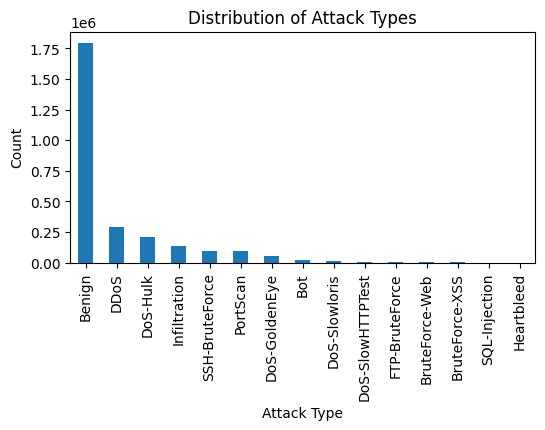

In [31]:
# visualize attack types distribution
attack_counts = df_small['label'].value_counts()
plt.figure(figsize=(6, 3))
attack_counts.plot(kind='bar')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()

In [32]:
df_small.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
flow_duration,2714913.0,1.681797e+07,3.483514e+07,1.000000,2093.000000,116907.000000,5.860439e+06,1.200000e+08
flow_bytes_s,2714913.0,1.157209e+06,2.512428e+07,0.000000,55.952790,1748.330546,1.464010e+04,2.071000e+09
flow_packets_s,2714913.0,4.086948e+04,1.960017e+05,0.016701,1.312799,51.687600,1.367054e+03,4.000000e+06
fwd_packets_s,2714913.0,3.528174e+04,1.856405e+05,0.000000,0.814653,27.694241,8.833922e+02,3.000000e+06
bwd_packets_s,2714913.0,5.587738e+03,3.903105e+04,0.000000,0.133698,10.179205,6.692097e+01,2.000000e+06
total_fwd_packet,2714913.0,1.865361e+01,1.313336e+03,1.000000,2.000000,2.000000,6.000000e+00,2.203660e+05
total_bwd_packets,2714913.0,1.146966e+01,1.003747e+03,0.000000,1.000000,2.000000,6.000000e+00,2.919220e+05
packet_length_mean,2714913.0,1.835458e+02,3.068949e+02,0.000000,6.000000,67.333333,1.436316e+02,3.337143e+03
fwd_packet_length_mean,2714913.0,6.191898e+01,1.865006e+02,0.000000,6.000000,35.375000,5.600000e+01,5.940857e+03
bwd_packet_length_mean,2714913.0,3.269956e+02,6.107603e+02,0.000000,4.000000,97.470588,2.410000e+02,5.800500e+03


In [33]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2714913 entries, 0 to 3999984
Data columns (total 22 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   flow_duration               float64
 1   flow_bytes_s                float64
 2   flow_packets_s              float64
 3   fwd_packets_s               float64
 4   bwd_packets_s               float64
 5   total_fwd_packet            int64  
 6   total_bwd_packets           int64  
 7   packet_length_mean          float64
 8   fwd_packet_length_mean      float64
 9   bwd_packet_length_mean      float64
 10  down_up_ratio               int64  
 11  syn_flag_count              int64  
 12  ack_flag_count              int64  
 13  rst_flag_count              int64  
 14  psh_flag_count              int64  
 15  fin_flag_count              int64  
 16  dst_port                    int64  
 17  protocol                    int64  
 18  total_length_of_fwd_packet  int64  
 19  total_length_of_bwd_packet

In [34]:
# Multiclass labels 
print("MULTICLASS LABEL DISTRIBUTION  (Label column)")

label_counts = df_small['label'].value_counts()
label_pct    = df_small['label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count"      : label_counts,
    "Percentage" : label_pct.round(3)
})
print(summary.to_string())
print(df_small['binary_label'].value_counts())

MULTICLASS LABEL DISTRIBUTION  (Label column)
                    Count  Percentage
label                                
Benign            1796460      66.170
DDoS               293934      10.827
DoS-Hulk           206205       7.595
Infiltration       134103       4.939
SSH-BruteForce      93981       3.462
PortScan            90618       3.338
DoS-GoldenEye       51633       1.902
Bot                 21542       0.793
DoS-Slowloris       13963       0.514
DoS-SlowHTTPTest     5227       0.193
FTP-BruteForce       4310       0.159
BruteForce-Web       1950       0.072
BruteForce-XSS        876       0.032
SQL-Injection         100       0.004
Heartbleed             11       0.000
binary_label
0    1796460
1     918453
Name: count, dtype: int64


## Split x and y

In [35]:
# features and target
X = df_small.drop(columns=["label", "binary_label"], errors="ignore").copy()
y = df_small["binary_label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (2714913, 20)
y shape: (2714913,)
binary_label
0    1796460
1     918453
Name: count, dtype: int64


## checking outliers + caping for supervised 

In [36]:
# outlier_report = []

# for col in X.columns:
#     q1 = X[col].quantile(0.25)
#     q3 = X[col].quantile(0.75)
#     iqr = q3 - q1
    
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr
    
#     outliers = ((X[col] < lower) | (X[col] > upper)).sum()
#     percent = outliers / len(X) * 100
    
#     outlier_report.append({
#         "feature": col,
#         "outliers": outliers,
#         "percent": percent
#     })

# outlier_report = pd.DataFrame(outlier_report).sort_values("percent", ascending=False)
# outlier_report.head(20)

In [37]:
# def cap_outliers_iqr(df):
#     df = df.copy()
#     for col in df.columns:
#         q1 = df[col].quantile(0.25)
#         q3 = df[col].quantile(0.75)
#         iqr = q3 - q1
        
#         lower = q1 - 1.5 * iqr
#         upper = q3 + 1.5 * iqr
        
#         df[col] = df[col].clip(lower=lower, upper=upper)
#     return df

## Unsupervised pipeline

In [38]:
# normal only data-set
X_normal = X[y == 0].copy()
X_attack = X[y == 1].copy()

print("Normal only:", X_normal.shape)
print("Attack only:", X_attack.shape)

print("Normal ratio in full dataset:", (y == 0).mean())
print("Attack ratio in full dataset:", (y == 1).mean())

Normal only: (1796460, 20)
Attack only: (918453, 20)
Normal ratio in full dataset: 0.6617007616818661
Attack ratio in full dataset: 0.33829923831813397


In [39]:
# split normal for training
X_train_unsup, X_val_normal_unsup = train_test_split(
    X_normal,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

X_train_unsup = X_train_unsup.sample(frac=0.8, random_state=42)  #reduce contamination risk in training set

print("Unsupervised train normal:", X_train_unsup.shape)
print("Unsupervised val normal:  ", X_val_normal_unsup.shape)

Unsupervised train normal: (1149734, 20)
Unsupervised val normal:   (359292, 20)


In [40]:
# mixed validation/test from full X and y
X_val_unsup, X_test_unsup, y_val_unsup, y_test_unsup = train_test_split(
    X, y,
    test_size=0.50,
    stratify=y,
    random_state=42
)

print("Unsupervised mixed val:", X_val_unsup.shape, y_val_unsup.shape)
print("Unsupervised mixed test:", X_test_unsup.shape, y_test_unsup.shape)

Unsupervised mixed val: (1357456, 20) (1357456,)
Unsupervised mixed test: (1357457, 20) (1357457,)


In [41]:
skewness = X_train_unsup.skew(numeric_only=True)

skewed_cols = skewness[abs(skewness) > 1].sort_values(ascending=False)

print(skewed_cols)
print("Number of skewed features:", len(skewed_cols))

protocol                      283.152353
total_length_of_bwd_packet    197.288898
total_bwd_packets             196.733618
total_fwd_packet              196.355196
total_length_of_fwd_packet    125.749209
rst_flag_count                 51.381650
flow_bytes_s                   39.012107
bwd_packets_s                  23.875477
down_up_ratio                  17.904156
fin_flag_count                  9.713224
fwd_packet_length_mean          7.489582
fwd_packets_s                   6.548303
flow_packets_s                  6.385868
syn_flag_count                  3.680509
packet_length_mean              3.415214
bwd_packet_length_mean          3.054028
flow_duration                   2.422647
dst_port                        1.530072
dtype: float64
Number of skewed features: 18


In [42]:
import numpy as np

# binary / flag-like features (0/1)
binary_cols = [
    "syn_flag_count",
    "ack_flag_count",
    "rst_flag_count",
    "psh_flag_count",
    "fin_flag_count"
]

# ensure they exist (safe check)
binary_cols = [c for c in binary_cols if c in X_train_unsup.columns]

skewness = X_train_unsup.skew(numeric_only=True)

skewed_cols = skewness[abs(skewness) > 1].index.tolist()

# remove binary features from skewed list (important)
skewed_cols = [c for c in skewed_cols if c not in binary_cols]

for col in skewed_cols:
    for df in [X_train_unsup, X_val_normal_unsup, X_val_unsup, X_test_unsup]:
        df[col] = np.log1p(df[col])

In [43]:
outlier_report = []

for col in X_train_unsup.columns:
    q1 = X_train_unsup[col].quantile(0.25)
    q3 = X_train_unsup[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((X_train_unsup[col] < lower) | (X_train_unsup[col] > upper)).sum()
    percent = (outliers / len(X_train_unsup)) * 100

    outlier_report.append({
        "feature": col,
        "outlier_count": outliers,
        "outlier_percent": percent
    })

outlier_df = pd.DataFrame(outlier_report).sort_values("outlier_percent", ascending=False)

print(outlier_df.head(20))

                       feature  outlier_count  outlier_percent
16                    dst_port         246537        21.442960
6            total_bwd_packets          75436         6.561170
11              syn_flag_count          69759         6.067403
5             total_fwd_packet          19293         1.678040
4                bwd_packets_s          17452         1.517916
8       fwd_packet_length_mean          16124         1.402411
15              fin_flag_count          11812         1.027368
10               down_up_ratio          10995         0.956308
19  total_length_of_bwd_packet           5347         0.465064
1                 flow_bytes_s           2664         0.231706
18  total_length_of_fwd_packet            592         0.051490
13              rst_flag_count            435         0.037835
17                    protocol             30         0.002609
3                fwd_packets_s              0         0.000000
0                flow_duration              0         0

In [44]:
# scaling
# robust_scaler_unsup = RobustScaler()
# standard_scaler_unsup = StandardScaler()

# X_train_unsup_robust = robust_scaler_unsup.fit_transform(X_train_unsup) 
# X_val_normal_unsup_robust = robust_scaler_unsup.transform(X_val_normal_unsup)
# X_val_unsup_robust = robust_scaler_unsup.transform(X_val_unsup)
# X_test_unsup_robust = robust_scaler_unsup.transform(X_test_unsup)

# X_train_unsup_scaled = standard_scaler_unsup.fit_transform(X_train_unsup_robust)
# X_val_normal_unsup_scaled = standard_scaler_unsup.transform(X_val_normal_unsup_robust)
# X_val_unsup_scaled = standard_scaler_unsup.transform(X_val_unsup_robust)
# X_test_unsup_scaled = standard_scaler_unsup.transform(X_test_unsup_robust)

robust_scaler_unsup = RobustScaler()

X_train_unsup_scaled = robust_scaler_unsup.fit_transform(X_train_unsup)

X_val_normal_unsup_scaled = robust_scaler_unsup.transform(X_val_normal_unsup)
X_val_unsup_scaled = robust_scaler_unsup.transform(X_val_unsup)
X_test_unsup_scaled = robust_scaler_unsup.transform(X_test_unsup)

print("Unsupervised train normal scaled:", X_train_unsup_scaled.shape)
print("Unsupervised val normal scaled:  ", X_val_normal_unsup_scaled.shape)
print("Unsupervised mixed val scaled:   ", X_val_unsup_scaled.shape)
print("Unsupervised mixed test scaled:  ", X_test_unsup_scaled.shape)

Unsupervised train normal scaled: (1149734, 20)
Unsupervised val normal scaled:   (359292, 20)
Unsupervised mixed val scaled:    (1357456, 20)
Unsupervised mixed test scaled:   (1357457, 20)


In [45]:
output_dir = Path("processed_outputs")
output_dir.mkdir(exist_ok=True)

joblib.dump(X_train_unsup_scaled, output_dir / "X_train_unsupervised_scaled.pkl")
joblib.dump(X_val_normal_unsup_scaled, output_dir / "X_val_normal_unsupervised_scaled.pkl")

joblib.dump(X_val_unsup_scaled, output_dir / "X_val_unsupervised_scaled.pkl")
joblib.dump(X_test_unsup_scaled, output_dir / "X_test_unsupervised_scaled.pkl")

joblib.dump(y_val_unsup, output_dir / "y_val_unsupervised.pkl")
joblib.dump(y_test_unsup, output_dir / "y_test_unsupervised.pkl")

joblib.dump(robust_scaler_unsup, output_dir / "robust_scaler_unsupervised.pkl")
# joblib.dump(standard_scaler_unsup, output_dir / "standard_scaler_unsupervised.pkl")

print("Unsupervised files saved.")

Unsupervised files saved.


In [46]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, output_dir / "feature_names.pkl")

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 20
['flow_duration', 'flow_bytes_s', 'flow_packets_s', 'fwd_packets_s', 'bwd_packets_s', 'total_fwd_packet', 'total_bwd_packets', 'packet_length_mean', 'fwd_packet_length_mean', 'bwd_packet_length_mean', 'down_up_ratio', 'syn_flag_count', 'ack_flag_count', 'rst_flag_count', 'psh_flag_count', 'fin_flag_count', 'dst_port', 'protocol', 'total_length_of_fwd_packet', 'total_length_of_bwd_packet']


## Supervised pipeline

In [59]:
# Attack labels in CICIDS-2018 (exclude 'Benign')
attack_df = df_small[df_small['label'] != 'Benign'].copy()

print(f"Attack samples only: {len(attack_df)}")
print(attack_df['label'].value_counts())

Attack samples only: 918453
label
DDoS                293934
DoS-Hulk            206205
Infiltration        134103
SSH-BruteForce       93981
PortScan             90618
DoS-GoldenEye        51633
Bot                  21542
DoS-Slowloris        13963
DoS-SlowHTTPTest      5227
FTP-BruteForce        4310
BruteForce-Web        1950
BruteForce-XSS         876
SQL-Injection          100
Heartbleed              11
Name: count, dtype: int64


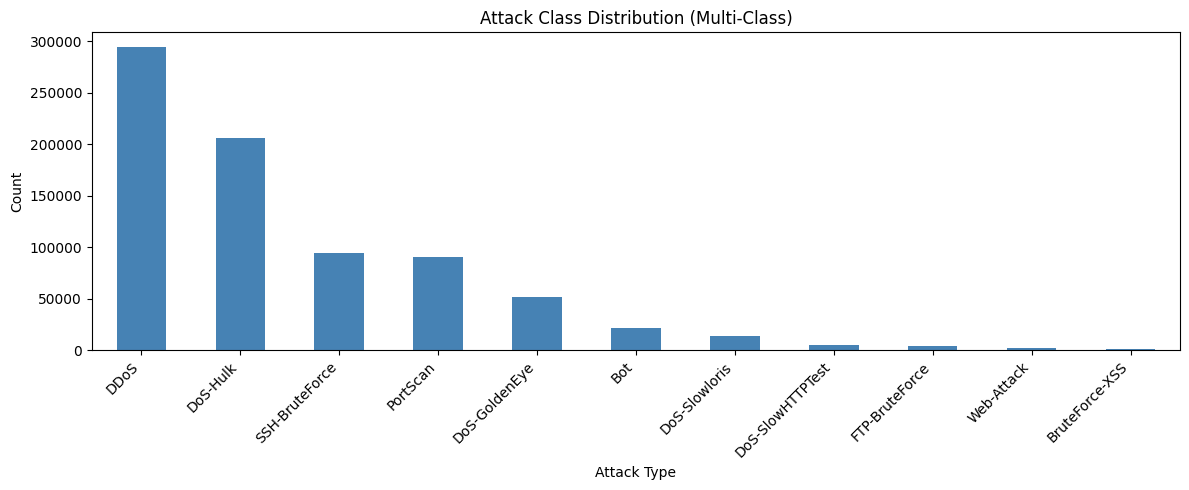

In [60]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title("Attack Class Distribution (Multi-Class)")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [61]:
# features and target
X = attack_df.drop(columns=["label", "binary_label"], errors="ignore").copy()
y = attack_df["label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (918453, 20)
y shape: (918453,)
label
DDoS                293934
DoS-Hulk            206205
Infiltration        134103
SSH-BruteForce       93981
PortScan             90618
DoS-GoldenEye        51633
Bot                  21542
DoS-Slowloris        13963
DoS-SlowHTTPTest      5227
FTP-BruteForce        4310
BruteForce-Web        1950
BruteForce-XSS         876
SQL-Injection          100
Heartbleed              11
Name: count, dtype: int64


In [62]:
print(y.value_counts())

label
DDoS                293934
DoS-Hulk            206205
Infiltration        134103
SSH-BruteForce       93981
PortScan             90618
DoS-GoldenEye        51633
Bot                  21542
DoS-Slowloris        13963
DoS-SlowHTTPTest      5227
FTP-BruteForce        4310
BruteForce-Web        1950
BruteForce-XSS         876
SQL-Injection          100
Heartbleed              11
Name: count, dtype: int64


In [63]:
# Drop Heartbleed
attack_df = attack_df[attack_df['label'] != 'Heartbleed'].copy()
print(f"After dropping Heartbleed  : {len(attack_df):,}")

# Drop Infiltration
attack_df = attack_df[attack_df['label'] != 'Infiltration'].copy()
print(f"After dropping Infiltration: {len(attack_df):,}")

# Merge SQL-Injection + BruteForce-Web → Web-Attack
attack_df['label'] = attack_df['label'].replace({
    'SQL-Injection'  : 'Web-Attack',
    'BruteForce-Web' : 'Web-Attack'
})

After dropping Heartbleed  : 918,442
After dropping Infiltration: 784,339


In [64]:
print("Final Class Distribution:")
print(attack_df['label'].value_counts())
print(f"\nTotal samples : {len(attack_df):,}")
print(f"Total classes : {attack_df['label'].nunique()}")

Final Class Distribution:
label
DDoS                293934
DoS-Hulk            206205
SSH-BruteForce       93981
PortScan             90618
DoS-GoldenEye        51633
Bot                  21542
DoS-Slowloris        13963
DoS-SlowHTTPTest      5227
FTP-BruteForce        4310
Web-Attack            2050
BruteForce-XSS         876
Name: count, dtype: int64

Total samples : 784,339
Total classes : 11


In [65]:
X = attack_df.drop(columns=['label', 'binary_label'], errors='ignore').copy()
y = attack_df['label'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (784339, 20)
y shape: (784339,)


In [66]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nClass Mapping:")
for i, cls in enumerate(le.classes_):
    count = (y == cls).sum()
    print(f"  {i} → {cls:<25} ({count:>7,} samples)")


Class Mapping:
  0 → Bot                       ( 21,542 samples)
  1 → BruteForce-XSS            (    876 samples)
  2 → DDoS                      (293,934 samples)
  3 → DoS-GoldenEye             ( 51,633 samples)
  4 → DoS-Hulk                  (206,205 samples)
  5 → DoS-SlowHTTPTest          (  5,227 samples)
  6 → DoS-Slowloris             ( 13,963 samples)
  7 → FTP-BruteForce            (  4,310 samples)
  8 → PortScan                  ( 90,618 samples)
  9 → SSH-BruteForce            ( 93,981 samples)
  10 → Web-Attack                (  2,050 samples)


In [67]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nSplit Sizes:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")


Split Sizes:
  Train : (549037, 20)
  Val   : (117651, 20)
  Test  : (117651, 20)


In [68]:
#Scaling (fit ONLY on train)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [69]:
from imblearn.over_sampling import SMOTE
#SMOTE — Oversample minorities (on train only)
sampling_targets_over = {
    le.transform(['BruteForce-XSS'])[0]  : 10000,
    le.transform(['Web-Attack'])[0]       : 10000,
    le.transform(['DoS-SlowHTTPTest'])[0] : 15000,
    le.transform(['FTP-BruteForce'])[0]   : 15000,
}

smote = SMOTE(
    sampling_strategy=sampling_targets_over,
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"\nAfter SMOTE:")
print(f"  Train shape: {X_train_res.shape}")


After SMOTE:
  Train shape: (590313, 20)


In [70]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_res),
    y=y_train_res
)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:")
for idx, w in class_weight_dict.items():
    print(f"  {le.classes_[idx]:<25} weight: {w:.4f}")

Class Weights:
  Bot                       weight: 3.5589
  BruteForce-XSS            weight: 5.3665
  DDoS                      weight: 0.2608
  DoS-GoldenEye             weight: 1.4848
  DoS-Hulk                  weight: 0.3718
  DoS-SlowHTTPTest          weight: 3.5777
  DoS-Slowloris             weight: 5.4906
  FTP-BruteForce            weight: 3.5777
  PortScan                  weight: 0.8460
  SSH-BruteForce            weight: 0.8157
  Web-Attack                weight: 5.3665


In [71]:
import numpy as np

print("Final Training Class Distribution:")
unique, counts = np.unique(y_train_res, return_counts=True)

sorted_idx = np.argsort(counts)[::-1]

for cls_idx, cnt in zip(unique[sorted_idx], counts[sorted_idx]):
    bar = '█' * (cnt // 5000)
    print(f"  {le.classes_[cls_idx]:<25} {cnt:>7,}  {bar}")

print(f"\n  Total training samples: {len(y_train_res):,}")

Final Training Class Distribution:
  DDoS                      205,754  █████████████████████████████████████████
  DoS-Hulk                  144,343  ████████████████████████████
  SSH-BruteForce             65,787  █████████████
  PortScan                   63,433  ████████████
  DoS-GoldenEye              36,143  ███████
  Bot                        15,079  ███
  FTP-BruteForce             15,000  ███
  DoS-SlowHTTPTest           15,000  ███
  Web-Attack                 10,000  ██
  BruteForce-XSS             10,000  ██
  DoS-Slowloris               9,774  █

  Total training samples: 590,313


In [72]:
# Save Everything
output_dir = Path("processed_outputs")
output_dir.mkdir(exist_ok=True)

# Resampled train (use this for model training)
joblib.dump(X_train_res,        output_dir / "X_train_supervised.pkl")
joblib.dump(y_train_res,        output_dir / "y_train_supervised.pkl")

# Original scaled val/test (never resample these)
joblib.dump(X_val_scaled,       output_dir / "X_val_supervised.pkl")
joblib.dump(X_test_scaled,      output_dir / "X_test_supervised.pkl")
joblib.dump(y_val,              output_dir / "y_val_supervised.pkl")
joblib.dump(y_test,             output_dir / "y_test_supervised.pkl")

# Artifacts
joblib.dump(scaler,             output_dir / "scaler_supervised.pkl")
joblib.dump(le,                 output_dir / "label_encoder_supervised.pkl")
joblib.dump(class_weight_dict,  output_dir / "class_weights_supervised.pkl")

print("\nAll files saved to processed_outputs")


All files saved to processed_outputs
